In [7]:
import os, joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os 
from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC


In [54]:
from ucimlrepo import fetch_ucirepo

In [9]:
heart_disease = fetch_ucirepo(id=45)

X = heart_disease.data.features
y = heart_disease.data.targets.rename(
    columns={"num":"target"}
)
y["target"] = (y["target"]>0).astype(int)
print(heart_disease.metadata)

{'uci_id': 45, 'name': 'Heart Disease', 'repository_url': 'https://archive.ics.uci.edu/dataset/45/heart+disease', 'data_url': 'https://archive.ics.uci.edu/static/public/45/data.csv', 'abstract': '4 databases: Cleveland, Hungary, Switzerland, and the VA Long Beach', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 303, 'num_features': 13, 'feature_types': ['Categorical', 'Integer', 'Real'], 'demographics': ['Age', 'Sex'], 'target_col': ['num'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 1989, 'last_updated': 'Fri Nov 03 2023', 'dataset_doi': '10.24432/C52P4X', 'creators': ['Andras Janosi', 'William Steinbrunn', 'Matthias Pfisterer', 'Robert Detrano'], 'intro_paper': {'ID': 231, 'type': 'NATIVE', 'title': 'International application of a new probability algorithm for the diagnosis of coronary artery disease.', 'authors': 'R. Detrano, A. Jánosi, W. Steinbrunn, M

In [10]:
X.isna().sum()

X = X.dropna()

In [57]:
!pip install seaborn

In [11]:
X["thal"] = X["thal"].astype(int)
y = y.loc[X.index]

In [59]:
df = pd.concat([X, y], axis=1)
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3,1
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3,0


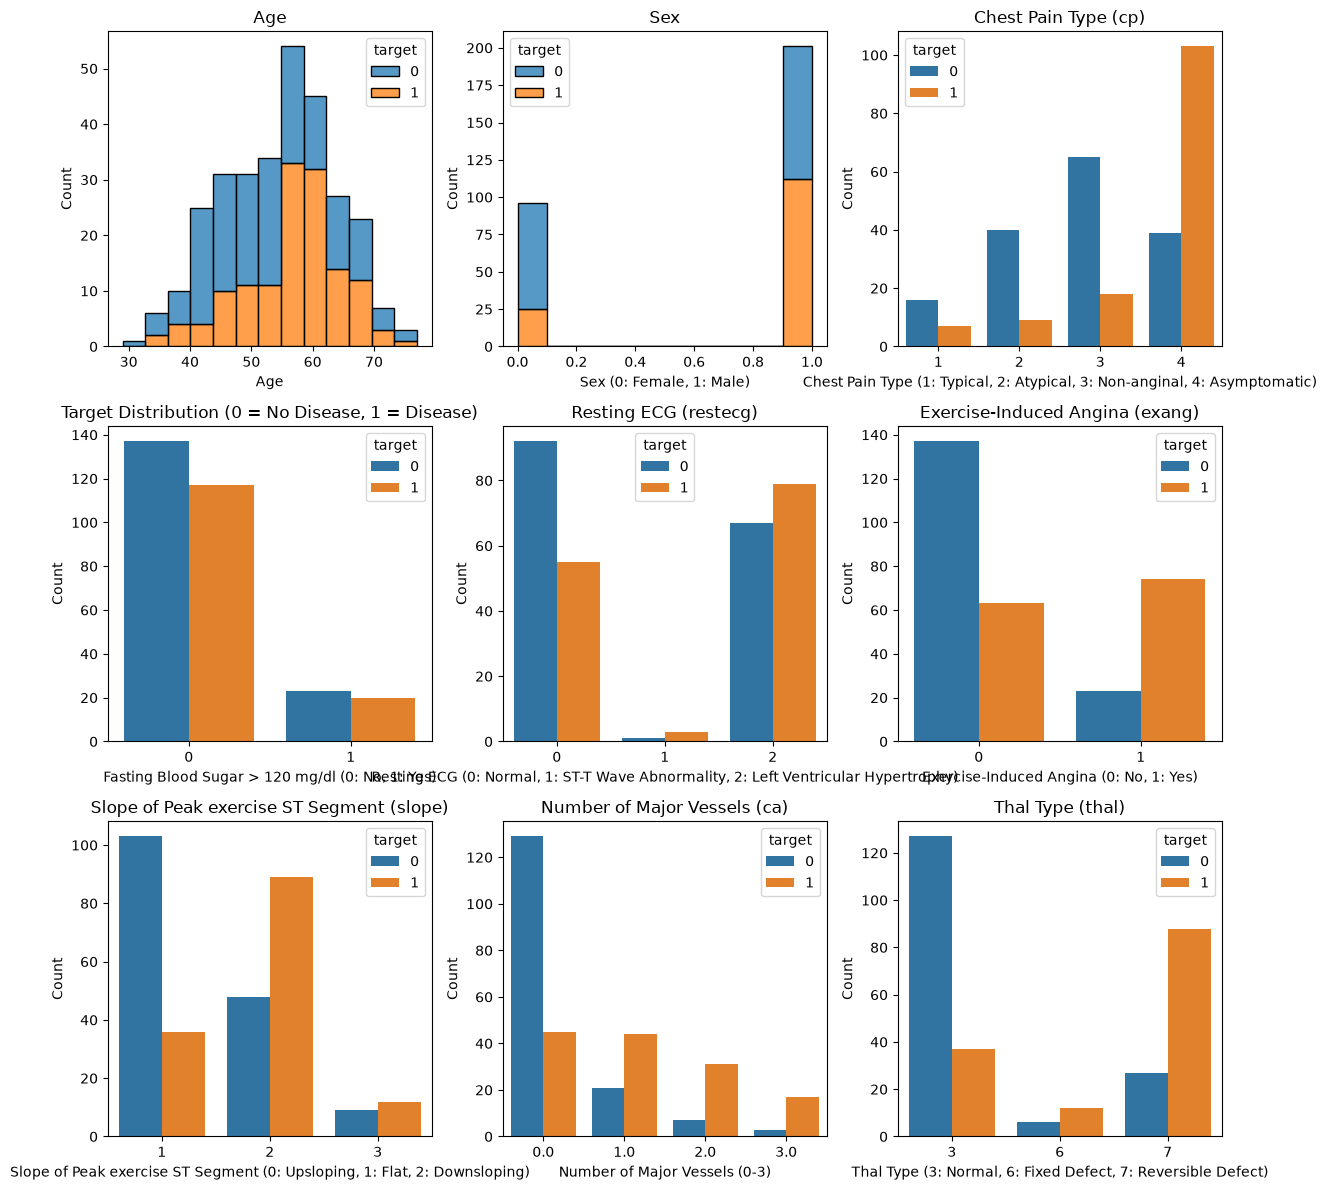

In [60]:
# Plot target variable distribution
plt.figure(figsize=(12, 12))

# Age vs Heart Disease
plt.subplot(3, 3, 1)
sns.histplot(x='age', hue='target', data=df, multiple="stack")
plt.title("Age")
plt.xlabel("Age")
plt.ylabel("Count")

# Sex vs Heart Disease
plt.subplot(3, 3, 2)
sns.histplot(x='sex', hue='target', data=df, multiple="stack")
plt.title("Sex")
plt.xlabel("Sex (0: Female, 1: Male)")
plt.ylabel("Count")

# Chest Pain vs Heart Disease
plt.subplot(3, 3, 3)
sns.countplot(x='cp', hue='target', data=df)
plt.title("Chest Pain Type (cp)")
plt.xlabel("Chest Pain Type (1: Typical, 2: Atypical, 3: Non-anginal, 4: Asymptomatic)")
plt.ylabel("Count")

# Fasting Blood Sugar vs Heart Disease
plt.subplot(3, 3, 4)
sns.countplot(x='fbs', hue='target', data=df)
plt.title("Target Distribution (0 = No Disease, 1 = Disease)")
plt.xlabel("Fasting Blood Sugar > 120 mg/dl (0: No, 1: Yes)")
plt.ylabel("Count")

# Resting ECG Type vs Heart Disease
plt.subplot(3, 3, 5)
sns.countplot(x='restecg', hue='target', data=df)
plt.title("Resting ECG (restecg)")
plt.xlabel("Resting ECG (0: Normal, 1: ST-T Wave Abnormality, 2: Left Ventricular Hypertrophy)")
plt.ylabel("Count")

# Exercise-Induced Angina vs Heart Disease
plt.subplot(3, 3, 6)
sns.countplot(x='exang', hue='target', data=df)
plt.title("Exercise-Induced Angina (exang)")
plt.xlabel("Exercise-Induced Angina (0: No, 1: Yes)")
plt.ylabel("Count")

# Slope of Peak exercise ST segment vs Heart Disease
plt.subplot(3, 3, 7)
sns.countplot(x='slope', hue='target', data=df)
plt.title("Slope of Peak exercise ST Segment (slope)")
plt.xlabel("Slope of Peak exercise ST Segment (0: Upsloping, 1: Flat, 2: Downsloping)")
plt.ylabel("Count")

# Number of Major Vessels vs Heart Disease
plt.subplot(3, 3, 8)
sns.countplot(x='ca', hue='target', data=df)
plt.title("Number of Major Vessels (ca)")
plt.xlabel("Number of Major Vessels (0-3)")
plt.ylabel("Count")

# Thal Type vs Heart Disease
plt.subplot(3, 3, 9)
sns.countplot(x='thal', hue='target', data=df)
plt.title("Thal Type (thal)")
plt.xlabel("Thal Type (3: Normal, 6: Fixed Defect, 7: Reversible Defect)")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

In [12]:
categorical_cols = [ 'cp', 'restecg','slope','thal']
X[categorical_cols] = X[categorical_cols].astype(str)

X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True, dtype=int)

print("Original Features Shape:", X.shape)
print("Encoded Features Shape:", X_encoded.shape)
print(X_encoded.head())

Original Features Shape: (297, 13)
Encoded Features Shape: (297, 18)
   age  sex  trestbps  chol  fbs  thalach  exang  oldpeak   ca  cp_2  cp_3  \
0   63    1       145   233    1      150      0      2.3  0.0     0     0   
1   67    1       160   286    0      108      1      1.5  3.0     0     0   
2   67    1       120   229    0      129      1      2.6  2.0     0     0   
3   37    1       130   250    0      187      0      3.5  0.0     0     1   
4   41    0       130   204    0      172      0      1.4  0.0     1     0   

   cp_4  restecg_1  restecg_2  slope_2  slope_3  thal_6  thal_7  
0     0          0          1        0        1       1       0  
1     1          0          1        1        0       0       0  
2     1          0          1        1        0       0       1  
3     0          0          0        0        1       0       0  
4     0          0          1        0        0       0       0  


In [13]:
from sklearn.preprocessing import OneHotEncoder

continuous_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak','ca']
binary_cols = ['sex', 'fbs', 'exang']

scaler = StandardScaler()
X_encoded[continuous_cols] = scaler.fit_transform(X_encoded[continuous_cols])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), continuous_cols),
        ("cat", OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore"), categorical_cols),
        ("bin", "passthrough", binary_cols)
    ]
)

In [6]:
##Train Test Split and Modeling
X_train, X_test, y_train, y_test = train_test_split(X, y["target"], test_size=0.2, random_state=42)

X_train_preprocessed = preprocessor.fit_transform(X_train)

##Save preprocessor artifact
Models_dir = "models"
if not os.path.exists(Models_dir):
    os.makedirs(Models_dir)
preprocessor_path = os.path.join(Models_dir, "preprocessor.pkl")
joblib.dump(preprocessor, preprocessor_path)
print(f"Preprocessor saved to {preprocessor_path}")

## Grid Search for Hyperparameter Tuning
model_params = {
    "logistic_regression": {
        "model": LogisticRegression(max_iter=1000, random_state=42),
        "params": {"C": [0.01, 0.1, 1.0, 10.0], "solver": ["liblinear", "lbfgs"]}
    },
    "knn": {
        "model": KNeighborsClassifier(),
        "params": {"n_neighbors": [3, 5, 7, 9, 11], "weights": ["uniform", "distance"]}
    },
    "decision_tree": {
        "model": DecisionTreeClassifier(random_state=42),
        "params": {"max_depth": [3, 5, 7, 10, None], "criterion": ["gini", "entropy"]}
    },
    "random_forest": {
        "model": RandomForestClassifier(random_state=42),
        "params": {"n_estimators": [50, 100, 200], "max_depth": [3, 5, 10, None]}
    },
    "svm": {
        "model": SVC(probability=True, random_state=42),
        "params": {"C": [0.1, 1, 10], "kernel": ["linear", "rbf"]}
    }
}

# Transform test data using the fitted preprocessor
X_test_preprocessed = preprocessor.transform(X_test)


NameError: name 'train_test_split' is not defined

In [67]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report

for name, mp in model_params.items():

    clf = GridSearchCV(mp["model"], mp["params"], cv=5, scoring="accuracy", n_jobs=-1)
    clf.fit(X_train_preprocessed, y_train)
    best_model = clf.best_estimator_
    y_pred = best_model.predict(X_test_preprocessed)
    model_path = os.path.join(Models_dir, f"model_{name}.pkl")
    joblib.dump(best_model, model_path)

    print(f"Saved {name} model to '{model_path}' (CV Accuracy: {clf.best_score_:.4f})")
    print(f"Model: {name}")
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("Classification Report:\n", classification_report(y_test, y_pred))

Saved logistic_regression model to 'models\model_logistic_regression.pkl' (CV Accuracy: 0.8354)
Model: logistic_regression
Confusion Matrix:
 [[33  3]
 [ 4 20]]
Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.92      0.90        36
           1       0.87      0.83      0.85        24

    accuracy                           0.88        60
   macro avg       0.88      0.88      0.88        60
weighted avg       0.88      0.88      0.88        60

Saved knn model to 'models\model_knn.pkl' (CV Accuracy: 0.7848)
Model: knn
Confusion Matrix:
 [[31  5]
 [ 5 19]]
Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.86      0.86        36
           1       0.79      0.79      0.79        24

    accuracy                           0.83        60
   macro avg       0.83      0.83      0.83        60
weighted avg       0.83      0.83      0.83        60

Saved decision_tree mode

c:\Users\DELL\Desktop\New folder\Python\venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


Saved svm model to 'models\model_svm.pkl' (CV Accuracy: 0.8522)
Model: svm
Confusion Matrix:
 [[33  3]
 [ 6 18]]
Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.92      0.88        36
           1       0.86      0.75      0.80        24

    accuracy                           0.85        60
   macro avg       0.85      0.83      0.84        60
weighted avg       0.85      0.85      0.85        60



In [1]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import learning_curve
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

In [13]:
MODELS_DIR = "models"

model_files = {
    "Logistic Regression": "model_logistic_regression.pkl",
    "KNN": "model_knn.pkl",
    "Decision Tree": "model_decision_tree.pkl",
    "Random Forest": "model_random_forest.pkl",
    "SVM": "model_svm.pkl"
}

models = {}

for name, file in model_files.items():
    models[name] = joblib.load(os.path.join(MODELS_DIR, file))

print("Models loaded successfully!")

for name in models:
    print(name)

Models loaded successfully!
Logistic Regression
KNN
Decision Tree
Random Forest
SVM


c:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py:525: InconsistentVersionWarning: Trying to unpickle estimator LogisticRegression from version 1.9.1 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py:525: InconsistentVersionWarning: Trying to unpickle estimator KNeighborsClassifier from version 1.9.1 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py:525: InconsistentVersionWarning: Trying to unpickle 

In [14]:
results = []

for name, model in models.items():

    y_pred = model.predict(X_test_preprocessed)
    y_prob = model.predict_proba(X_test_preprocessed)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

results_df = pd.DataFrame(results)

# Round values
results_df = results_df.round(4)

print(results_df)

                 Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
0  Logistic Regression    0.8833     0.8696  0.8333    0.8511   0.9398
1                  KNN    0.8333     0.7917  0.7917    0.7917   0.8993
2        Decision Tree    0.8000     0.7143  0.8333    0.7692   0.9016
3        Random Forest    0.8833     0.8400  0.8750    0.8571   0.9549
4                  SVM    0.8500     0.8571  0.7500    0.8000   0.9213


In [15]:
comparison_df = results_df.copy()

metric_columns = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score",
    "ROC-AUC"
]

comparison_df[metric_columns] = comparison_df[metric_columns] * 100

comparison_df[metric_columns] = comparison_df[metric_columns].round(2)

comparison_df

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,88.33,86.96,83.33,85.11,93.98
1,KNN,83.33,79.17,79.17,79.17,89.93
2,Decision Tree,80.00,71.43,83.33,76.92,90.16
3,Random Forest,88.33,84.00,87.50,85.71,95.49
4,SVM,85.00,85.71,75.00,80.00,92.13


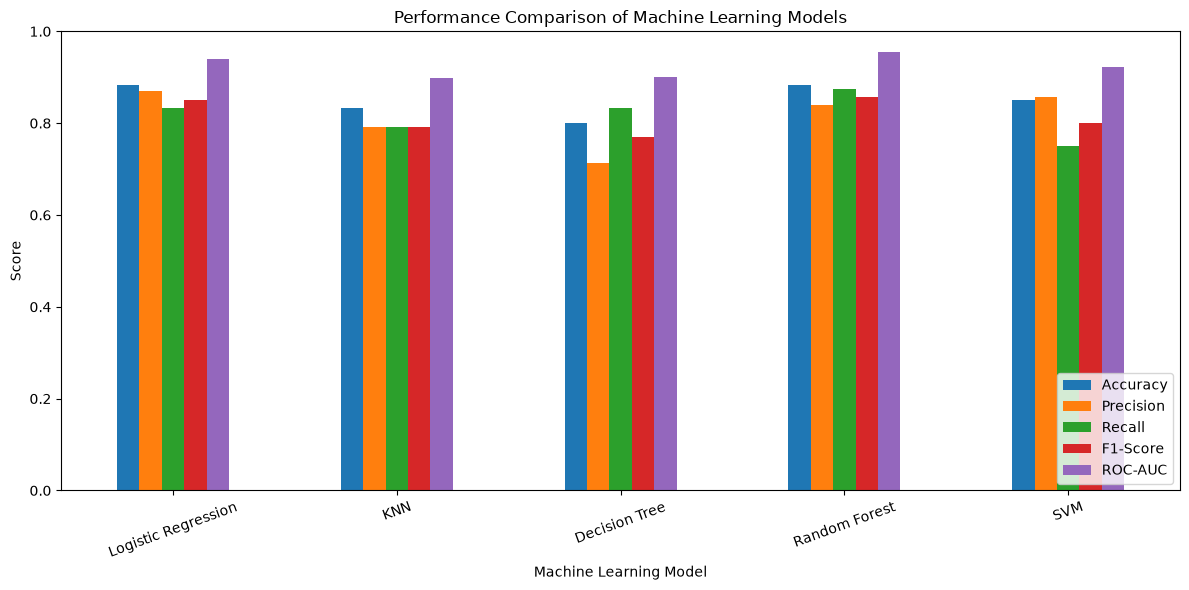

In [16]:
plot_df = results_df.set_index("Model")

plot_df[[
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score",
    "ROC-AUC"
]].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Performance Comparison of Machine Learning Models")
plt.xlabel("Machine Learning Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.legend(loc="lower right")
plt.tight_layout()

plt.savefig(
    "model_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

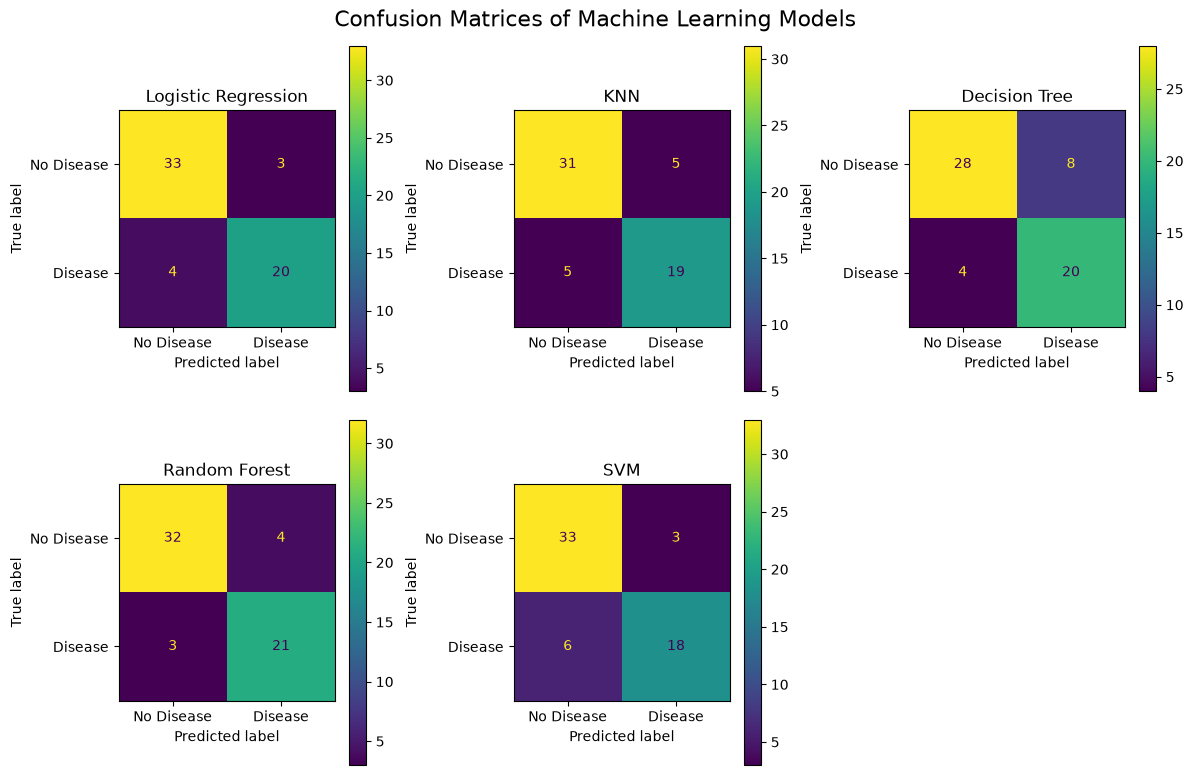

In [18]:
fig, axes = plt.subplots(2, 3, figsize=(12, 8))

axes = axes.ravel()

for i, (name, model) in enumerate(models.items()):

    y_pred = model.predict(X_test_preprocessed)

    cm = confusion_matrix(y_test, y_pred)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["No Disease", "Disease"]
    )

    disp.plot(
        ax=axes[i],
        values_format="d"
    )

    axes[i].set_title(name)

# Hide unused 6th subplot
axes[-1].axis("off")

plt.suptitle(
    "Confusion Matrices of Machine Learning Models",
    fontsize=16
)

plt.tight_layout()

plt.savefig(
    "confusion_matrices.png",
    dpi=300,
    bbox_inches="tight"
 )

plt.show()

<Figure size 500x400 with 0 Axes>

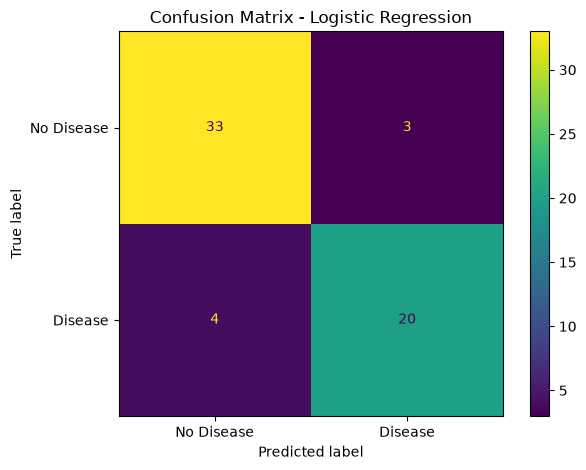

<Figure size 500x400 with 0 Axes>

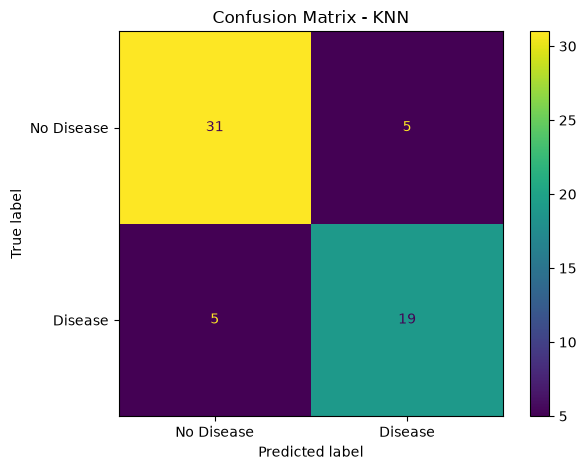

<Figure size 500x400 with 0 Axes>

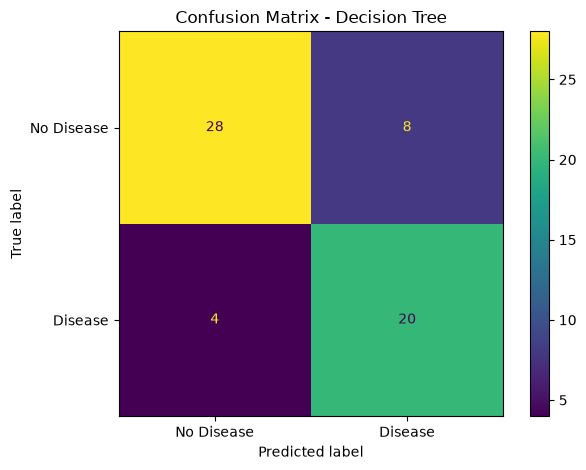

<Figure size 500x400 with 0 Axes>

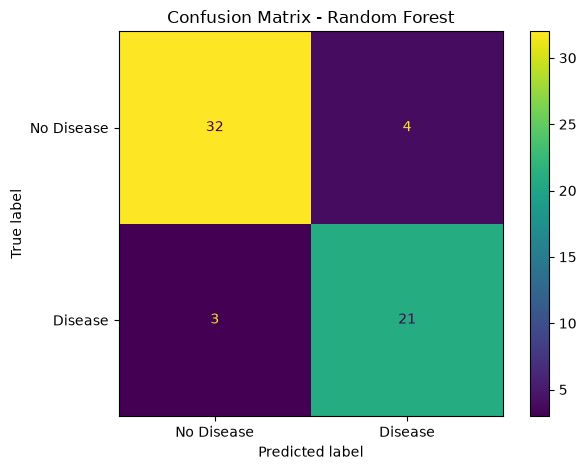

<Figure size 500x400 with 0 Axes>

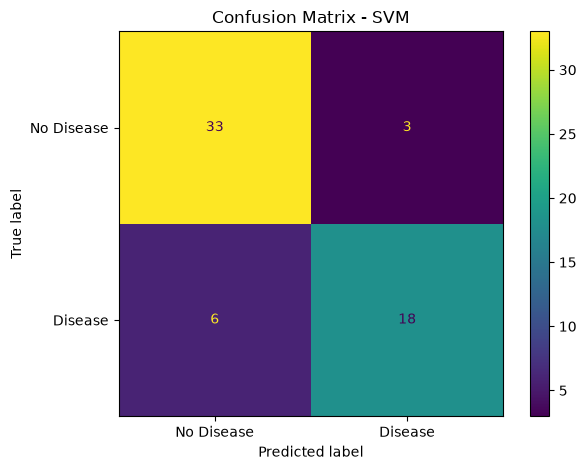

In [20]:
for name, model in models.items():

    y_pred = model.predict(X_test_preprocessed)

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(5, 4))

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["No Disease", "Disease"]
    )

    disp.plot(
        values_format="d"
    )

    plt.title(f"Confusion Matrix - {name}")

    plt.tight_layout()

    filename = name.lower().replace(" ", "_") + "_confusion_matrix.png"

    plt.savefig(
        filename,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# Create fresh model objects for learning curves
learning_models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    "KNN": KNeighborsClassifier(),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        random_state=42
    ),

    "SVM": SVC(
        probability=True,
        random_state=42
    )
}

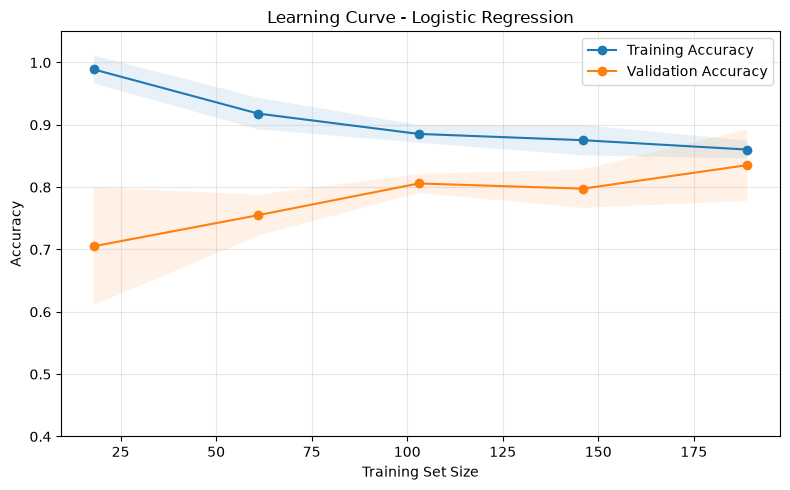

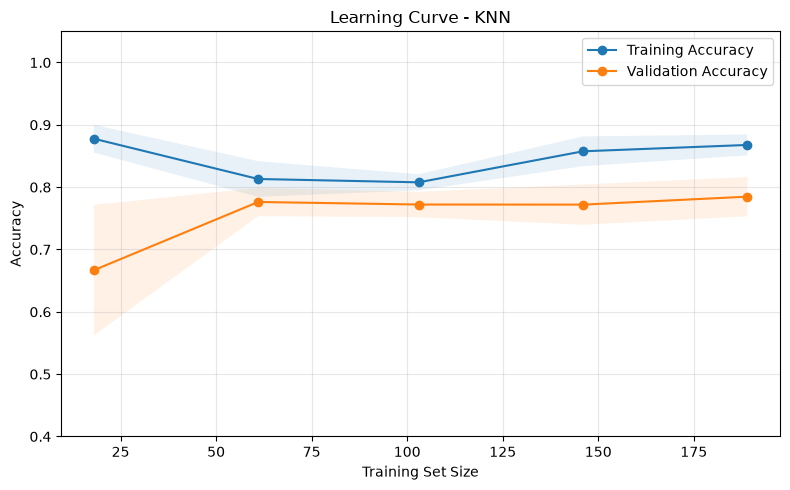

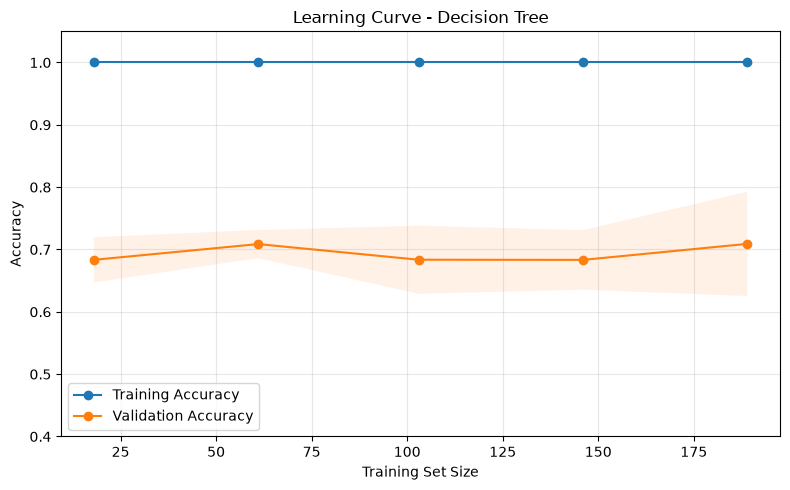

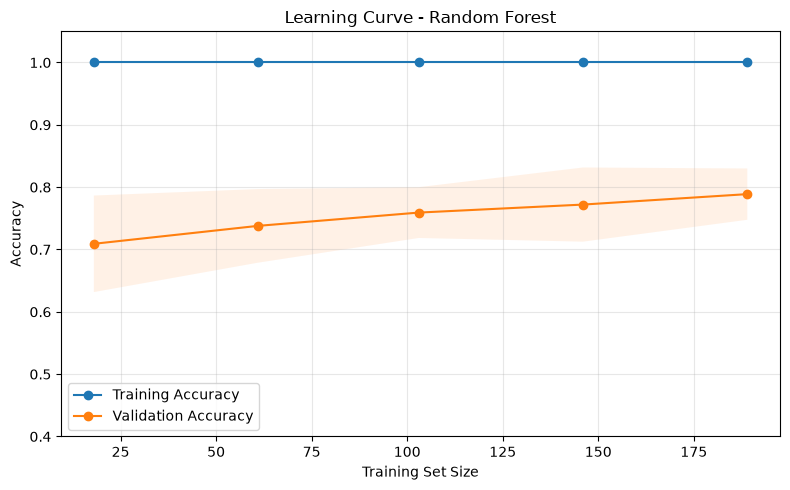

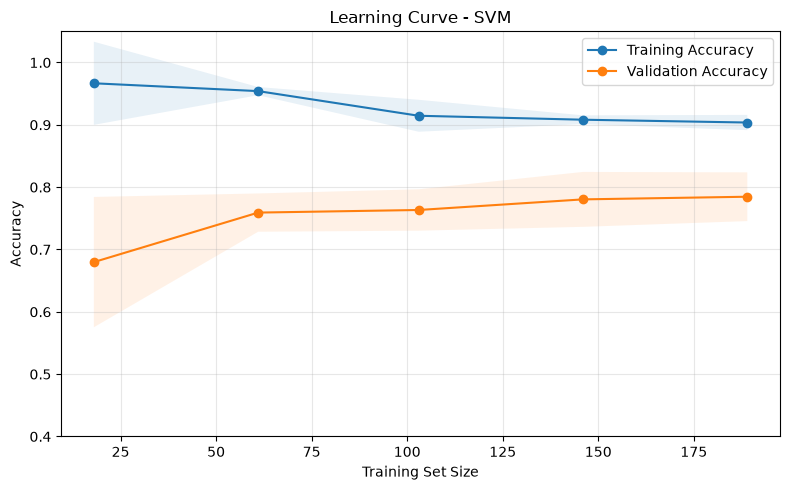

In [14]:
from sklearn.model_selection import learning_curve, train_test_split

if "X_train_preprocessed" not in globals():
    X_train, _, y_train, _ = train_test_split(
        X,
        y["target"],
        test_size=0.2,
        random_state=42
    )
    X_train_preprocessed = preprocessor.fit_transform(X_train)

for name, model in learning_models.items():

    train_sizes, train_scores, validation_scores = learning_curve(
        model,
        X_train_preprocessed,
        y_train,
        cv=5,
        scoring="accuracy",
        train_sizes=np.linspace(0.1, 1.0, 5),
        n_jobs=-1
    )

    train_mean = train_scores.mean(axis=1)
    train_std = train_scores.std(axis=1)

    validation_mean = validation_scores.mean(axis=1)
    validation_std = validation_scores.std(axis=1)

    plt.figure(figsize=(8, 5))

    plt.plot(
        train_sizes,
        train_mean,
        marker="o",
        label="Training Accuracy"
    )

    plt.plot(
        train_sizes,
        validation_mean,
        marker="o",
        label="Validation Accuracy"
    )

    plt.fill_between(
        train_sizes,
        train_mean - train_std,
        train_mean + train_std,
        alpha=0.1
    )

    plt.fill_between(
        train_sizes,
        validation_mean - validation_std,
        validation_mean + validation_std,
        alpha=0.1
    )

    plt.title(f"Learning Curve - {name}")
    plt.xlabel("Training Set Size")
    plt.ylabel("Accuracy")
    plt.ylim(0.4, 1.05)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    filename = name.lower().replace(" ", "_") + "_learning_curve.png"

    plt.savefig(
        filename,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

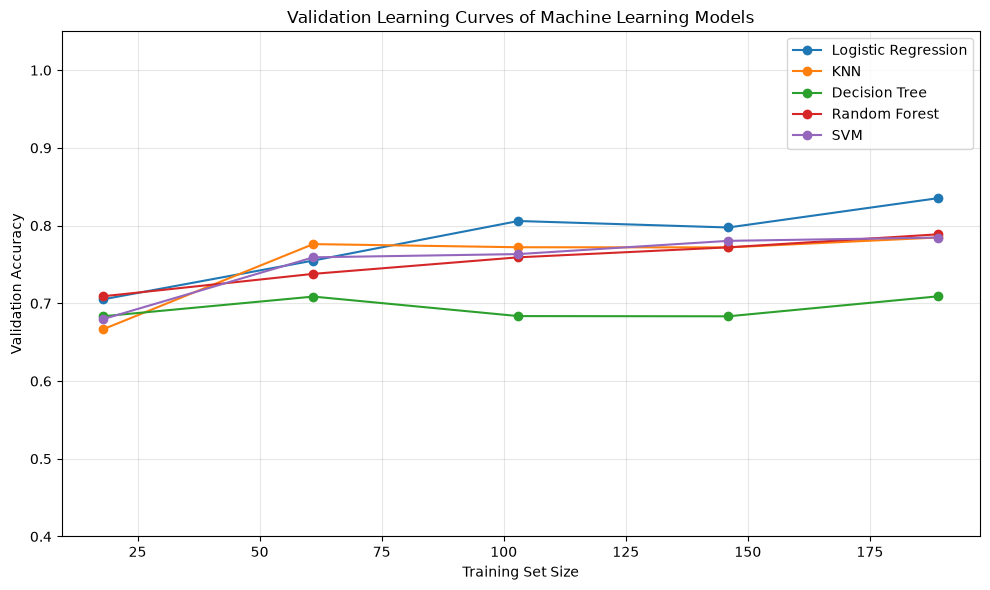

In [16]:
plt.figure(figsize=(10, 6))

for name, model in learning_models.items():

    train_sizes, train_scores, validation_scores = learning_curve(
        model,
        X_train_preprocessed,
        y_train,
        cv=5,
        scoring="accuracy",
        train_sizes=np.linspace(0.1, 1.0, 5),
        n_jobs=-1
    )

    validation_mean = validation_scores.mean(axis=1)

    plt.plot(
        train_sizes,
        validation_mean,
        marker="o",
        label=name
    )

plt.title("Validation Learning Curves of Machine Learning Models")
plt.xlabel("Training Set Size")
plt.ylabel("Validation Accuracy")
plt.ylim(0.4, 1.05)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(
    "combined_learning_curves.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [20]:
import os
import joblib
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split

if "models" not in globals():
    MODELS_DIR = "models"
    model_files = {
        "Logistic Regression": "model_logistic_regression.pkl",
        "KNN": "model_knn.pkl",
        "Decision Tree": "model_decision_tree.pkl",
        "Random Forest": "model_random_forest.pkl",
        "SVM": "model_svm.pkl"
    }

    models = {}
    for name, file in model_files.items():
        models[name] = joblib.load(os.path.join(MODELS_DIR, file))

if "X_test_preprocessed" not in globals() or "y_test" not in globals():
    if "preprocessor" not in globals():
        preprocessor = joblib.load(os.path.join("models", "preprocessor.pkl"))

    if "X_train" not in globals() or "X_test" not in globals() or "y_train" not in globals() or "y_test" not in globals():
        X_train, X_test, y_train, y_test = train_test_split(
            X,
            y["target"],
            test_size=0.2,
            random_state=42
        )

    X_test_preprocessed = preprocessor.transform(X_test)

if "results_df" not in globals():
    results = []

    for name, model in models.items():
        y_pred = model.predict(X_test_preprocessed)
        y_prob = model.predict_proba(X_test_preprocessed)[:, 1]

        results.append({
            "Model": name,
            "Accuracy": accuracy_score(y_test, y_pred),
            "Precision": precision_score(y_test, y_pred),
            "Recall": recall_score(y_test, y_pred),
            "F1-Score": f1_score(y_test, y_pred),
            "ROC-AUC": roc_auc_score(y_test, y_prob)
        })

    results_df = pd.DataFrame(results).round(4)

best_accuracy_model = results_df.loc[
    results_df["Accuracy"].idxmax()
]

best_f1_model = results_df.loc[
    results_df["F1-Score"].idxmax()
]

best_auc_model = results_df.loc[
    results_df["ROC-AUC"].idxmax()
]

print("Best Accuracy:")
print(best_accuracy_model)

print("\nBest F1-Score:")
print(best_f1_model)

print("\nBest ROC-AUC:")
print(best_auc_model)


Best Accuracy:
Model        Logistic Regression
Accuracy                  0.8833
Precision                 0.8696
Recall                    0.8333
F1-Score                  0.8511
ROC-AUC                   0.9398
Name: 0, dtype: object

Best F1-Score:
Model        Random Forest
Accuracy            0.8833
Precision             0.84
Recall               0.875
F1-Score            0.8571
ROC-AUC             0.9549
Name: 3, dtype: object

Best ROC-AUC:
Model        Random Forest
Accuracy            0.8833
Precision             0.84
Recall               0.875
F1-Score            0.8571
ROC-AUC             0.9549
Name: 3, dtype: object


In [23]:
from sklearn.metrics import confusion_matrix

cm_results = []

for name, model in models.items():

    y_pred = model.predict(X_test_preprocessed)

    tn, fp, fn, tp = confusion_matrix(
        y_test,
        y_pred
    ).ravel()

    cm_results.append({
        "Model": name,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp
    })

cm_df = pd.DataFrame(cm_results)

cm_df

,Model,TN,FP,FN,TP
0,Logistic Regression,33,3,4,20
1,KNN,31,5,5,19
2,Decision Tree,28,8,4,20
3,Random Forest,32,4,3,21
4,SVM,33,3,6,18


In [25]:
if "comparison_df" not in globals():
    comparison_df = results_df.copy()
    metric_columns = [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC"
    ]
    comparison_df[metric_columns] = (
        comparison_df[metric_columns] * 100
    ).round(2)

comparison_df.to_csv(
    "model_comparison_results.csv",
    index=False
)

cm_df.to_csv(
    "confusion_matrix_results.csv",
    index=False
)

print("Results saved successfully!")

Results saved successfully!
